<a href="https://colab.research.google.com/github/saman0101/Deep-Exploratory-Analysis-Feature-Engineering-Baseline-Modeling/blob/main/DEA_%26_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Loading Dataset**

In [2]:
df = pd.read_csv('/content/Steel_industry_data.csv')
df

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.00,0.0,73.21,100.00,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.00,0.0,66.77,100.00,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.00,0.0,70.28,100.00,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.00,0.0,68.09,100.00,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.00,0.0,64.72,100.00,4500,Weekday,Monday,Light_Load
...,...,...,...,...,...,...,...,...,...,...,...
35035,31/12/2018 23:00,3.85,4.86,0.00,0.0,62.10,100.00,82800,Weekday,Monday,Light_Load
35036,31/12/2018 23:15,3.74,3.74,0.00,0.0,70.71,100.00,83700,Weekday,Monday,Light_Load
35037,31/12/2018 23:30,3.78,3.17,0.07,0.0,76.62,99.98,84600,Weekday,Monday,Light_Load
35038,31/12/2018 23:45,3.78,3.06,0.11,0.0,77.72,99.96,85500,Weekday,Monday,Light_Load


**2.Extracting Coloumns From the date Column**

In [3]:
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y %H:%M')
df['hour'] = df['date'].dt.hour
df['Day_of_Month'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['week_day'] = df['date'].dt.weekday
df

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,hour,Day_of_Month,month,year,week_day
0,2018-01-01 00:15:00,3.17,2.95,0.00,0.0,73.21,100.00,900,Weekday,Monday,Light_Load,0,1,1,2018,0
1,2018-01-01 00:30:00,4.00,4.46,0.00,0.0,66.77,100.00,1800,Weekday,Monday,Light_Load,0,1,1,2018,0
2,2018-01-01 00:45:00,3.24,3.28,0.00,0.0,70.28,100.00,2700,Weekday,Monday,Light_Load,0,1,1,2018,0
3,2018-01-01 01:00:00,3.31,3.56,0.00,0.0,68.09,100.00,3600,Weekday,Monday,Light_Load,1,1,1,2018,0
4,2018-01-01 01:15:00,3.82,4.50,0.00,0.0,64.72,100.00,4500,Weekday,Monday,Light_Load,1,1,1,2018,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35035,2018-12-31 23:00:00,3.85,4.86,0.00,0.0,62.10,100.00,82800,Weekday,Monday,Light_Load,23,31,12,2018,0
35036,2018-12-31 23:15:00,3.74,3.74,0.00,0.0,70.71,100.00,83700,Weekday,Monday,Light_Load,23,31,12,2018,0
35037,2018-12-31 23:30:00,3.78,3.17,0.07,0.0,76.62,99.98,84600,Weekday,Monday,Light_Load,23,31,12,2018,0
35038,2018-12-31 23:45:00,3.78,3.06,0.11,0.0,77.72,99.96,85500,Weekday,Monday,Light_Load,23,31,12,2018,0


In [4]:
df.shape

(35040, 16)

# **Creating new Feature Power_Fator_Ratio from existing column**

In [4]:
df["Power_Factor_Ratio"] = (df["Leading_Current_Power_Factor"] / df["Lagging_Current_Power_Factor"])
df.head(5)

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,hour,Day_of_Month,month,year,week_day,Power_Factor_Ratio
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,1,1,2018,0,1.365934
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,1,1,2018,0,1.497679
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,1,1,2018,0,1.422880
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,1,1,2018,0,1.468644
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,1,1,2018,0,1.545117


# **Creating a binary feature High_Load**

In [5]:
threshold = df["Usage_kWh"].quantile(0.75)
df["High_Load"] = (df["Usage_kWh"] > threshold).astype(int)
df.head(3)

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,hour,Day_of_Month,month,year,week_day,Power_Factor_Ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,1,1,2018,0,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,1,1,2018,0,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,1,1,2018,0,1.422880,0


# **Detecting outliers using IQR Method**

Number of outliers: 328
                     date  Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
140   2018-01-02 11:15:00     128.52                                 70.85   
141   2018-01-02 11:30:00     144.47                                 78.48   
143   2018-01-02 12:00:00     123.30                                 66.06   
150   2018-01-02 13:45:00     124.45                                 49.79   
153   2018-01-02 14:30:00     129.10                                 53.50   
...                   ...        ...                                   ...   
33851 2018-12-19 15:00:00     145.22                                 70.67   
33853 2018-12-19 15:30:00     130.46                                 60.23   
33855 2018-12-19 16:00:00     125.21                                 58.43   
33856 2018-12-19 16:15:00     133.56                                 64.40   
33859 2018-12-19 17:00:00     125.50                                 50.69   

       Leading_Current_Reactive_Power_k

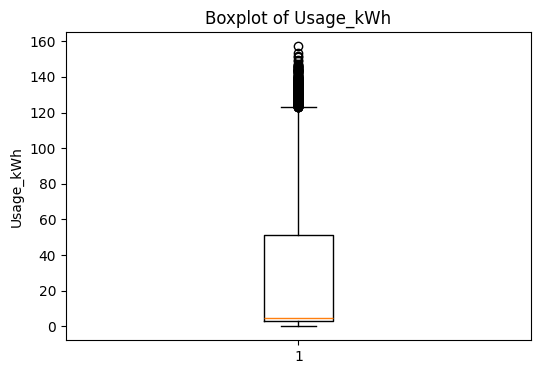

In [6]:
Q1 = df["Usage_kWh"].quantile(0.25)
Q3 = df["Usage_kWh"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df["Usage_kWh"] < lower_bound) | (df["Usage_kWh"] > upper_bound)]
print("Number of outliers:", len(outliers))
print(outliers)

plt.figure(figsize=(6, 4))
plt.boxplot(df["Usage_kWh"], vert=True)
plt.title("Boxplot of Usage_kWh")
plt.ylabel("Usage_kWh")
plt.show()

# **Correlation Heatmap**

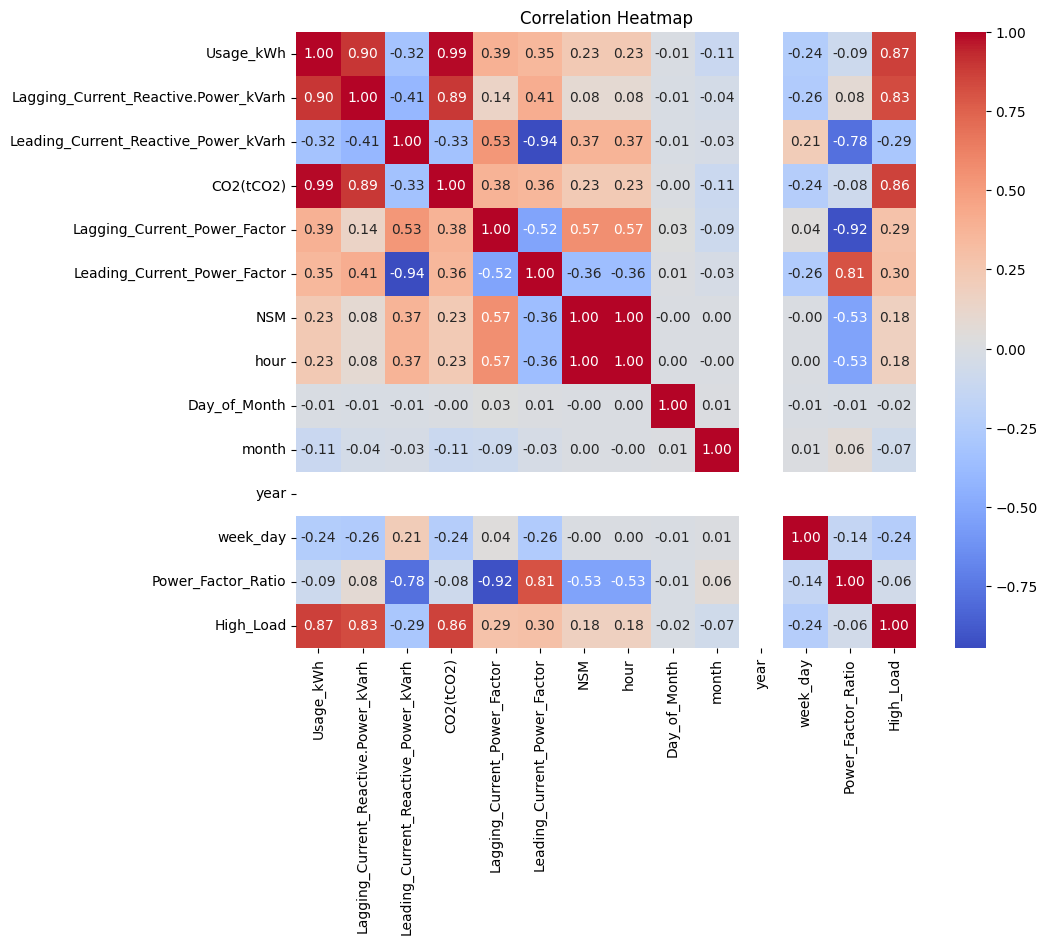

Top 3 features most correlated with Usage_kWh:
CO2(tCO2)                               0.98818
Lagging_Current_Reactive.Power_kVarh    0.89615
High_Load                               0.86784
Name: Usage_kWh, dtype: float64


In [7]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()
top_3 = (
    corr_matrix["Usage_kWh"]
    .drop("Usage_kWh")
    .abs()
    .sort_values(ascending=False)
    .head(3)
)

print("Top 3 features most correlated with Usage_kWh:")
print(top_3)

# **Grouped Bar Chart**

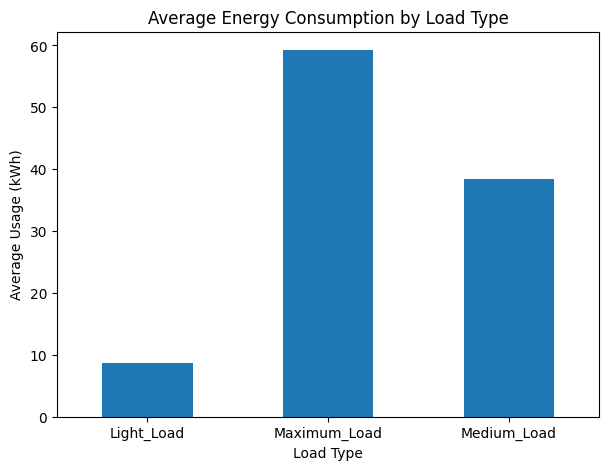

In [11]:
avg_usage = df.groupby("Load_Type")["Usage_kWh"].mean()
plt.figure(figsize=(7,5))
avg_usage.plot(kind="bar")
plt.title("Average Energy Consumption by Load Type")
plt.xlabel("Load Type")
plt.ylabel("Average Usage (kWh)")
plt.xticks(rotation=0)

plt.show()

# **Line Chart**

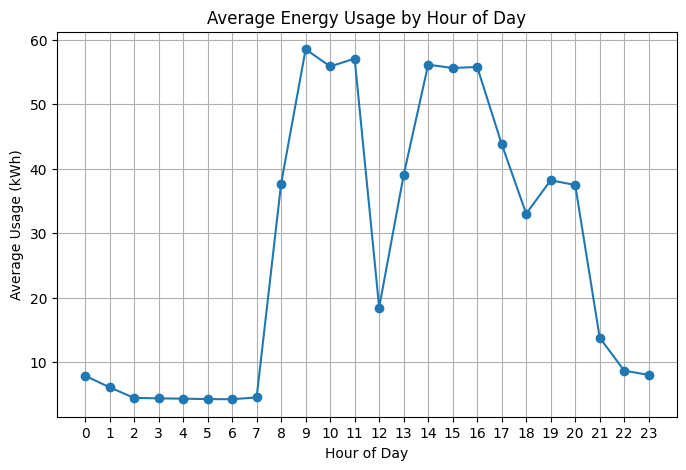

In [13]:
avg_usage = df.groupby("hour")["Usage_kWh"].mean()
plt.figure(figsize=(8, 5))
plt.plot(avg_usage.index, avg_usage.values, marker='o')
plt.title("Average Energy Usage by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Usage (kWh)")
plt.xticks(range(24))

plt.grid(True)
plt.show()

In [14]:
df.to_csv("engineered_dataset.csv", index=False)
from google.colab import files
files.download("engineered_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>